In [37]:
# exploring file, checking data types, null values, what we're working with
import pandas as pd
df = pd.read_csv('data/survey.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ResponseId              5000 non-null   int64  
 1   Age                     5000 non-null   str    
 2   EdLevel                 4995 non-null   str    
 3   Employment              5000 non-null   str    
 4   WorkExp                 4948 non-null   float64
 5   YearsCode               4979 non-null   float64
 6   DevType                 5000 non-null   str    
 7   OrgSize                 4470 non-null   str    
 8   ICorPM                  4398 non-null   str    
 9   RemoteWork              4447 non-null   str    
 10  Industry                4856 non-null   str    
 11  Country                 5000 non-null   str    
 12  Currency                5000 non-null   str    
 13  LanguageHaveWorkedWith  4651 non-null   str    
 14  DatabaseHaveWorkedWith  3948 non-null   str    
 15

In [38]:
# checking unique values in columns + how often they appear
df['Employment'].value_counts(dropna = False)

Employment
Employed                                                4215
Independent contractor, freelancer, or self-employed     589
Not employed                                              90
Student                                                   85
I prefer not to say                                       11
Retired                                                   10
Name: count, dtype: int64

In [39]:
# summary stats for employment column
# do unemployed/students/retired have salaries?
df.groupby('Employment')['annual_salary_usd'].describe()

,count,mean,std,min,25%,50%,75%,max
Employment,,,,,,,,
Employed,4189.0,98419.296968,110255.343980,1.0,44404.0,78890.0,124687.0,2500000.0
I prefer not to say,8.0,123224.750000,73254.599432,8718.0,78852.5,123007.5,156701.0,254851.0
"Independent contractor, freelancer, or self-employed",573.0,109948.616056,301837.486016,1.0,39006.0,78890.0,127616.0,6890299.0
Not employed,70.0,77120.757143,63359.371152,5.0,25242.0,73289.0,122250.0,250000.0
Retired,5.0,81580.800000,76350.143639,109.0,34804.0,72000.0,100991.0,200000.0
Student,71.0,20149.394366,26185.456231,19.0,5226.5,16242.0,26491.0,200000.0


In [40]:
# mins and maxs look weird lets look at outliers
# mins first
df.nsmallest(10, 'annual_salary_usd')[['Country', 'Currency', 'DevType', 'Employment', 'annual_salary_usd']]

,Country,Currency,DevType,Employment,annual_salary_usd
306,Indonesia,IDR\tIndonesian rupiah,"Developer, back-end",Employed,1.0
2192,Colombia,COP\tColombian peso,"Developer, AI apps or physical AI","Independent contractor, freelancer, or self-em...",1.0
2842,China,CNY\tChinese Yuan Renminbi,AI/ML engineer,Employed,1.0
3766,Bangladesh,USD United States dollar,Project manager,Employed,2.0
3142,Taiwan,TWD New Taiwan dollar,"Developer, front-end",Employed,3.0
3975,Colombia,COP\tColombian peso,AI/ML engineer,Employed,3.0
2984,China,CNY\tChinese Yuan Renminbi,"Developer, full-stack",Employed,4.0
1633,South Korea,KRW\tSouth Korean won,"Developer, back-end",Employed,5.0
2529,Iceland,PLN Polish zloty,Retired,Not employed,5.0
2681,Nigeria,NGN\tNigerian naira,"Developer, mobile",Employed,6.0


In [41]:
# maxs here
df.nlargest(10, 'annual_salary_usd')[['Country', 'Currency', 'DevType', 'Employment', 'annual_salary_usd']]

,Country,Currency,DevType,Employment,annual_salary_usd
3236,Ukraine,UAH Ukrainian hryvnia,"Developer, full-stack","Independent contractor, freelancer, or self-em...",6890299.0
1858,India,USD United States dollar,"Architect, software or solutions",Employed,2500000.0
2896,United States of America,USD United States dollar,"Developer, full-stack",Employed,2000000.0
4493,United States of America,USD United States dollar,"Developer, back-end",Employed,1950000.0
3294,Finland,EUR European Euro,"Architect, software or solutions",Employed,1740220.0
2083,United States of America,USD United States dollar,"Developer, back-end",Employed,1250000.0
2614,Netherlands,EUR European Euro,"Developer, back-end",Employed,1160147.0
1393,United States of America,USD United States dollar,"Developer, mobile",Employed,1006403.0
507,United States of America,USD United States dollar,"Developer, full-stack",Employed,1000000.0
522,India,USD United States dollar,"Developer, full-stack","Independent contractor, freelancer, or self-em...",1000000.0


In [42]:
df['annual_salary_usd'].describe()

count    4.916000e+03
mean     9.835268e+04
std      1.454344e+05
min      1.000000e+00
25%      4.176500e+04
50%      7.755900e+04
75%      1.239930e+05
max      6.890299e+06
Name: annual_salary_usd, dtype: float64

<Axes: >

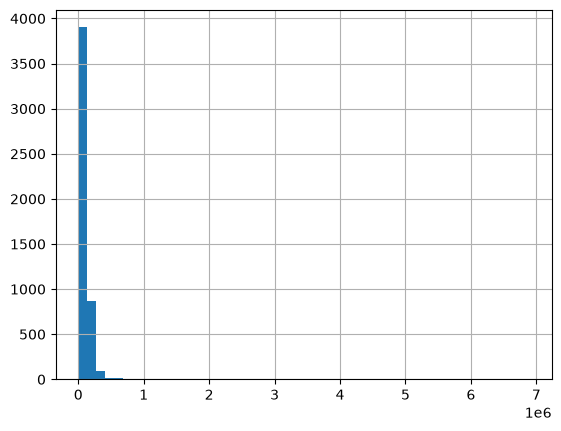

In [43]:
# salary distribution might look a little strange
df['annual_salary_usd'].hist(bins = 50)

In [44]:
# looking at salaries by percentile, can figure out from here what need to be cut
df['annual_salary_usd'].quantile([0.01, 0.05, 0.95, 0.99])

0.01        85.6
0.05      3988.0
0.95    232029.0
0.99    500000.0
Name: annual_salary_usd, dtype: float64

In [45]:
# cutting out outliers by percentile (1st, 99th)
lower = df['annual_salary_usd'].quantile(0.01)
upper = df['annual_salary_usd'].quantile(0.99)

# making sure values in cleaned salaries fall between 1st and 99th percentile
df_clean = df[(df['annual_salary_usd'] >= lower) & (df['annual_salary_usd'] <= upper)]

# seeing how many rows were dropped
print(f'Original rows: {len(df)}')
print(f'After filtering: {len(df_clean)}')

Original rows: 5000
After filtering: 4820


In [46]:
# checking if null rows were dropped by seeing how many are true
# percentile filtering handled them as a side effect, NaN failed both comparisons ig
df_clean['annual_salary_usd'].isna().sum()

np.int64(0)

<Axes: >

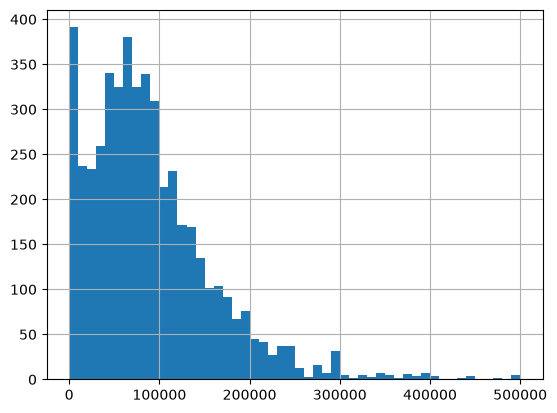

In [47]:
# checking data distribution now
# looks so much better
df_clean['annual_salary_usd'].hist(bins = 50)

## Cleaned 'annual_salary_usd'

**Notes:** The column had pretty noticeable issues, being 1) missing salaries and 2) very extreme outliers on both upper end and lower end. Extremely low values ($1 values) don't seem like real, meaningful salaries, while the extreme highs felt exceedingly high for plausible standards. Filtered rows to between 1st and 99th percentile, instead of choosing dollar amounts because it allowed the data to itself to decibe what would be considered as "extreme". Also made more sense to go by percentile instead of pinpointing a specfic dollar amount that to me was most realistic. Cutting off by percentile in turn also fixed the issue of NaN columns unexpectedly because rows with no value did not fit within the threshold anyway, so were dropped. Shown by new histogram distribution, data is right-skewed with most people earning lower to mid level salaries with a few high earners at the tail.

In [48]:
# looking distribution of nonmissing responses in 'OrgSize'
df_clean['OrgSize'].value_counts(dropna = False)

OrgSize
20 to 99 employees                                    939
100 to 499 employees                                  861
Less than 20 employees                                705
10,000 or more employees                              650
1,000 to 4,999 employees                              562
NaN                                                   464
500 to 999 employees                                  289
5,000 to 9,999 employees                              194
Just me - I am a freelancer, sole proprietor, etc.    110
I don’t know                                           46
Name: count, dtype: int64

In [49]:
# putting "I don't know" into missing category, doesn't have any numerical weight for the model
df_clean['OrgSize'] = df_clean['OrgSize'].replace("I don’t know", pd.NA)
df_clean['OrgSize'].isna().sum()

np.int64(510)

In [50]:
# wait looking at all together so i can keep as much meaningful data as possible
missing_values = df_clean.isna().sum().sort_values(ascending = False)
missing_percent = (missing_values / len(df_clean) * 100).round(2)
pd.DataFrame({'missing_count': missing_values, 'missing_percent': missing_percent})

,missing_count,missing_percent
DatabaseHaveWorkedWith,992,20.58
ICorPM,532,11.04
OrgSize,510,10.58
RemoteWork,485,10.06
LanguageHaveWorkedWith,320,6.64
Industry,101,2.10
WorkExp,39,0.81
YearsCode,17,0.35
EdLevel,5,0.10
ResponseId,0,0.00


In [51]:
# maybe can try filling modes with rows where cutting them would take out what's maybe usable data
for col in ['Industry', 'OrgSize', 'RemoteWork', 'ICorPM']:
    mode_value = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_value)

In [52]:
# let's verify data is clean with no missing values!
df_clean[['Industry', 'OrgSize', 'RemoteWork', 'ICorPM']].isna().sum()

Industry      0
OrgSize       0
RemoteWork    0
ICorPM        0
dtype: int64

In [53]:
# now dropping any rows that have missing values where data loss wouldn't be too significant
df_clean = df_clean.dropna(subset = ['WorkExp', 'YearsCode', 'EdLevel'])
print(f'Rows Remaining: {len(df_clean)}')

Rows Remaining: 4764


In [54]:
# since DatabaseHaveWorkedWith is highest let's see if it correlates with anything else
# it does! frontend professionals don't have any database experience so skip the question
# database administrators and engineers always fill it in
df_clean['db_missing'] = df_clean['DatabaseHaveWorkedWith'].isna()
df_clean.groupby('DevType')['db_missing'].mean().sort_values(ascending=False)

DevType
UX, Research Ops or UI design professional       1.000000
Developer, embedded applications or devices      0.655172
Developer, game or graphics                      0.645833
Developer, mobile                                0.522472
Applied scientist                                0.500000
Retired                                          0.500000
Student                                          0.461538
Other (please specify):                          0.434211
Developer, front-end                             0.399194
Academic researcher                              0.391304
Project manager                                  0.333333
System administrator                             0.333333
Financial analyst or engineer                    0.333333
Developer, desktop or enterprise applications    0.331950
Developer, AI apps or physical AI                0.307692
Support engineer or analyst                      0.285714
Developer, QA or test                            0.281250
Cybers

In [55]:
df_clean['DatabaseHaveWorkedWith'] = df_clean['DatabaseHaveWorkedWith'].fillna('None')

In [56]:
df_clean = df_clean.drop(columns = ['db_missing'])

In [57]:
df_clean.isna().sum()

ResponseId                  0
Age                         0
EdLevel                     0
Employment                  0
WorkExp                     0
YearsCode                   0
DevType                     0
OrgSize                     0
ICorPM                      0
RemoteWork                  0
Industry                    0
Country                     0
Currency                    0
LanguageHaveWorkedWith    314
DatabaseHaveWorkedWith      0
annual_salary_usd           0
dtype: int64

In [58]:
# since DatabaseHaveWorkedWith has the correlation with devtype maybe Languages does
# this is very different than Databases correlation, it feels more random
# think going to drop rows
df_clean['lang_missing'] = df_clean['LanguageHaveWorkedWith'].isna()
df_clean.groupby('DevType')['lang_missing'].mean().sort_values(ascending=False)

DevType
Retired                                          0.250000
System administrator                             0.166667
Support engineer or analyst                      0.142857
Cloud infrastructure engineer                    0.130435
Developer, AI apps or physical AI                0.115385
Academic researcher                              0.108696
Data engineer                                    0.088889
Student                                          0.076923
Developer, back-end                              0.076577
Architect, software or solutions                 0.075145
Developer, mobile                                0.073034
Engineering manager                              0.068376
Database administrator or engineer               0.066667
Developer, full-stack                            0.065318
Developer, front-end                             0.064516
Senior executive (C-suite, VP, etc.)             0.060000
Developer, embedded applications or devices      0.051724
Data s

In [59]:
df_clean = df_clean.dropna(subset = ['LanguageHaveWorkedWith'])
print(f'Rows Remaining: {len(df_clean)}')

Rows Remaining: 4450


In [60]:
df_clean = df_clean.drop(columns = ['lang_missing'])

In [61]:
df_clean.isna().sum()

ResponseId                0
Age                       0
EdLevel                   0
Employment                0
WorkExp                   0
YearsCode                 0
DevType                   0
OrgSize                   0
ICorPM                    0
RemoteWork                0
Industry                  0
Country                   0
Currency                  0
LanguageHaveWorkedWith    0
DatabaseHaveWorkedWith    0
annual_salary_usd         0
dtype: int64

## Cleaned rest of dataset
**Notes:** Decided to group the rest of the columns by how much data was missing instead of going column by column and the logic for each was inconsistent. For WorkExp, YearsCode, and EdLevel: dropped missing rows because the cost was very low. For rows where more data was missing (Industry, OrgSize, RemoteWork, ICorPM), filled rows with missing data with the mode to go with the most simple option instead of creating a seperate category. For Languages and Databases have worked with columns, they have multilabel data in the rows so I went about them differently. I wanted to test both for whether they correlated with DevType, because depending on the job they could impact each other. For Databases, result was a 0-100% spread that aligned with job function, where UI/UX roles skipped it and Database administrators did not. Assumed that non-responses meant doesn't use databases instead of random skipping so filled with "None". For Languages, the answers appeared more random and insignificant, so I dropped the rows. Result was going from 5000 --> 4450 rows for modeling! woohoo!

In [62]:
# checking for contradictions within the cleaned rows before moving onto encoding/modeling
# comparing professional experience to coding experience
exp_gap_rows = df_clean[df_clean['WorkExp'] > df_clean['YearsCode']]
print(f'Rows where WorkExp > YearsCode: {len(exp_gap_rows)}')
(exp_gap_rows['WorkExp'] - exp_gap_rows['YearsCode']).describe()

Rows where WorkExp > YearsCode: 176


count    176.000000
mean       6.823864
std        8.205761
min        1.000000
25%        3.000000
50%        5.000000
75%       10.000000
max       92.000000
dtype: float64

In [63]:
# maybe should check experience compared to what's reasonable for their age bracket
age_ceiling = {
    '18-24 years old': 24,
    '25-34 years old': 34,
    '35-44 years old': 44,
    '45-54 years old': 54,
    '55-64 years old': 64,
    '65 years and older': 90
}

df_clean['max_reasonable_age'] = df_clean['Age'].map(age_ceiling)

contradiction_rows = df_clean[
    (df_clean['WorkExp'] > df_clean['max_reasonable_age']) |
    (df_clean['YearsCode'] > df_clean['max_reasonable_age'])
]

contradiction_rows[['Age', 'WorkExp', 'YearsCode']]

,Age,WorkExp,YearsCode
3118,55-64 years old,100.0,8.0
3138,25-34 years old,35.0,4.0


In [64]:
# those two rows are impossible, let's drop them
df_clean = df_clean[
    ~((df_clean['WorkExp'] > df_clean['max_reasonable_age']) |
      (df_clean['YearsCode'] > df_clean['max_reasonable_age']))
      ]
print(f"Rows remaining: {len(df_clean)}")

Rows remaining: 4448


In [65]:
# getting rid of helper column
df_clean = df_clean.drop(columns = ['max_reasonable_age'])

## Checked for Cross-Column Consistency
**Notes:** Before moving onto encoding/modeling, I wanted to check whether there was any internal contradiction within rows that would be related, like Age, Work Experience, and Years Coding. Since the data has proven to be messy and shown some randomness, I was curious as to whether or not columns that should relate logically actually did. For WorkExp vs. YearsCode, 176 showed more professional work than years spent coding. This can be reasonable, because they could have been in a different profession prior to learning to becoming a developer. One row did show a 92 year gap, which feels morel like an error than a real-world scenario. For Experience vs. Age, I mapped each age bracket to its oldest plausible age, and flagged any rows where WorkExp or YearsCode exceeded that ceiling, which would be impossible. This caught only two rows, and my decision was to drop these two rows rather than treat them differently. Applied the same consistent rule instead of judging them by severity (one row was off by only a year). Result was 4450 rows --> 4448 rows.

# DATA PREP COMPLETE

In [66]:
# considering the currency column next, because salary target is already US denomiated
# might be helpful to just drop
df_clean = df_clean.drop(columns = ['Currency'])

In [67]:
# cardinality itself is very high for the Country column, looking at its distribution next
df_clean['Country'].value_counts().describe()

count    126.000000
mean      35.301587
std      102.879523
min        1.000000
25%        1.000000
50%        5.000000
75%       27.250000
max      989.000000
Name: count, dtype: float64

In [68]:
# checking how many countries have more or less than a certain number of respondants
# trying to decide whether or not keeping those 66 countries with >= 5 respondants is significant
# also checking what percentage of the total amount of countries they represent --> help decide if cutting needs to happen
for threshold in [5, 10, 20, 30]:
    n_countries = (df_clean['Country'].value_counts() >= threshold).sum()
    print(f'Countries with >= {threshold} respondants: {n_countries}')

Countries with >= 5 respondants: 66
Countries with >= 10 respondants: 53
Countries with >= 20 respondants: 39
Countries with >= 30 respondants: 31


In [69]:
# also checking what percentage of the total amount of countries they represent --> help decide if cutting needs to happen
for threshold in [5, 10, 20, 30]:
    counts = df_clean['Country'].value_counts()
    kept_countries = counts[counts >= threshold].index
    percent_covered = df_clean['Country'].isin(kept_countries).mean() * 100
    print(f'Threshold {threshold}: {len(kept_countries)} countries, covering {percent_covered: 1f}% of rows')

Threshold 5: 66 countries, covering  97.729317% of rows
Threshold 10: 53 countries, covering  95.795863% of rows
Threshold 20: 39 countries, covering  91.546763% of rows
Threshold 30: 31 countries, covering  87.230216% of rows


In [70]:
# deciding to keep everything above threshold 10
# countries fewer than 10 respondants might not have meaningful patterns for model
country_counts = df_clean['Country'].value_counts() # counts the occurence of unique values in a column
threshold_countries = country_counts[country_counts >= 10].index # pulls the country name, not just the count of the country

df_clean['Country'] = df_clean['Country'].where(
    df_clean['Country'].isin(threshold_countries), 'Other'
) # if country is in threshold countries, it stays. others with < 10 respondants get put into other

df_clean['Country'].value_counts()

Country
United States of America                                989
Germany                                                 407
United Kingdom of Great Britain and Northern Ireland    287
France                                                  206
India                                                   202
Other                                                   187
Canada                                                  161
Ukraine                                                 143
Italy                                                   118
Netherlands                                             116
Australia                                               114
Brazil                                                  112
Poland                                                  109
Spain                                                   106
Sweden                                                   87
Switzerland                                              73
Czech Republic                  

## Reducing "Country" Cardinality (large # of unique values, little to no repetition
**Notes:** The column 'Country' had 126 unique values, but the distribution was extremely skewed (median country had just 5 respondants, 25% had only 1). Encoding all 126 for the model would likely cause overfitting, since a country with just one respondant tells the model almost nothing generalizable to track a pattern on. Instead of picking a cutoff randomly, I decided to take a closer look at the number of respondants from each country and how many would be preserved at respondant thresholds of 5, 10, 20, and 30 minimum respondants per country. 

| Threshold | Countries kept | % of rows covered |
|---|---|---|
| 5  | 66 | 97.7% |
| 10 | 53 | 95.8% |
| 20 | 39 | 91.5% |
| 30 | 31 | 87.2% |

I decided to choose a threshold of 10 respondants. This would keep 53 countries as their own category, and cover 95.8% of the total available data we're working with. The "long tail" of countries with fewer than 10 respondants would be grouped into a category called "Other", which will cause no real consistency to be picked up on by the model. This is expected, and I thought it was an acceptable choice because 1 or 2 respondants from each country gives very little for the model to learn off of regardless. I thought that choosing this cuttoff would reduce overfitting and learning based off of noise instead of creating a false signal of sorts. Unfortunately, higher accuracy for the 53 common countries means that a tradeoff of having little to no information for people where responses were rarer.

**Also:** Decided to preemptively drop the 'Currency' column. Since 'annual_salary_usd' was also denominated in USD, I didn't think I needed 'Currency' for any type of conversion. Rough geographic grouping likely already overlaps with 'Country'. Keeping both would be redundant.

In [71]:
# checking what should be the final dataframe!!
df_clean.info()

<class 'pandas.DataFrame'>
Index: 4448 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ResponseId              4448 non-null   int64  
 1   Age                     4448 non-null   str    
 2   EdLevel                 4448 non-null   str    
 3   Employment              4448 non-null   str    
 4   WorkExp                 4448 non-null   float64
 5   YearsCode               4448 non-null   float64
 6   DevType                 4448 non-null   str    
 7   OrgSize                 4448 non-null   str    
 8   ICorPM                  4448 non-null   str    
 9   RemoteWork              4448 non-null   str    
 10  Industry                4448 non-null   str    
 11  Country                 4448 non-null   str    
 12  LanguageHaveWorkedWith  4448 non-null   str    
 13  DatabaseHaveWorkedWith  4448 non-null   str    
 14  annual_salary_usd       4448 non-null   float64
dtypes: 

In [72]:
# saving dataframe for next notebook, encoding and modeling
# splitting up so looks less overwhelming
df_clean.to_csv('data/cleaned_survey.csv', index = False)
print(f'Saved {len(df_clean)} rows to cleaned_survey.csv')

Saved 4448 rows to cleaned_survey.csv
